# Session 3, Notebook 2: Random Search and Successive Halving from Scratch

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 1, 13:30-14:25, Neural architecture search and loss balancing
**Slides:** `03a_Neural_Architecture_Search.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

Two search algorithms, written out in plain Python so that every line can be read: random
search (Bergstra and Bengio, 2012) and successive halving, the inner loop of Hyperband (Li et al.,
2018). Both are run on the same supervised testbed as `03_01`, a Genz Gaussian on $[0,1]^2$, and
then once more on a deep equilibrium net, the stochastic Brock-Mirman model of Session 2, where the
score is an Euler-equation error rather than a validation loss.

| Notebook | Question |
|:--|:--|
| `03_01_Grid_vs_Random_Search.ipynb` | Where to put a fixed number of trials |
| `03_02_NAS_RandomSearch_Hyperband.ipynb` (this notebook) | How to spend a fixed number of *epochs* |

Three things this notebook does that a first implementation usually gets wrong, and that the
slides warn about:

1. **Three data sets, not two.** Trials are ranked on a validation set; the test set is touched
   once, at the end, for the winner. A search that selects on the test set reports a number that is
   optimistic by construction.
2. **Successive halving continues training.** A survivor keeps its weights and optimizer state
   and trains for the additional epochs of the next rung. Retraining from scratch would pay each rung
   twice. The epoch budget is therefore exact: $27\cdot 8 + 9\cdot 16 + 3\cdot 48 = 504$ epochs
   against $30 \cdot 50 = 1500$ for random search.
3. **Several seeds.** One run of either method is one draw of a noisy statistic. The comparison is
   reported as a median with its range.

| Section | Topic |
|:--|:--|
| 1 | Testbed and the train / validation / test split |
| 2 | Baseline: a hand-picked architecture |
| 3 | Search space and the trial helper |
| 4 | Random search |
| 5 | Successive halving, with continuation |
| 6 | Comparison on the epoch axis, and the winner's surface |
| 7 | The same search on a DEQN |
| 8 | What to remember |

Sweeps are cached per preset in `nas_results/`. With the cache present the notebook runs in under
a minute; the teaching sweep from scratch takes about half an hour on a laptop CPU.

In [2]:
# ----------------------------------------------------------------
# Imports, plot style, cache location
# ----------------------------------------------------------------
import time
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "font.family":       "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

C_RANDOM, C_SHA, C_BASE, C_TRUE = "#e76f51", "#2a9d8f", "#6c757d", "#457b9d"

CACHE_DIR = Path("nas_results")
CACHE_DIR.mkdir(exist_ok=True)
GENZ_CACHE = CACHE_DIR / f"genz_search_{RUN_MODE}.pkl"
DEQN_CACHE = CACHE_DIR / f"deqn_search_{RUN_MODE}.pkl"

# The figures used in the slide deck are written by the teaching run.
FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")

T_NOTEBOOK = time.perf_counter()
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__} | RUN_MODE = {RUN_MODE} | caches: {GENZ_CACHE.name}, {DEQN_CACHE.name}")

2026-09-09 11:13:42.331104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788945222.357926  719215 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788945222.366989  719215 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 11:13:42.397711: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0 | RUN_MODE = teaching | caches: genz_search_teaching.pkl, deqn_search_teaching.pkl


---
## 1. Testbed and the split

The target is the Genz Gaussian on $[0,1]^2$,

$$f(\mathbf{x}) = \exp\!\Big(-\sum_{i=1}^{2} c_i^2 (x_i - w_i)^2\Big),$$

with the same $c, w$ as in `03_01`. Three disjoint samples: 1,000 training points, 1,000 validation
points for ranking trials, 2,000 test points that only the final winner sees.

In [3]:
d = 2
def genz_gaussian(X, c, w):
    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))

_r = np.random.RandomState(7)
c_param = _r.uniform(1.0, 3.0, size=d)
w_param = _r.uniform(0.2, 0.8, size=d)

n_train, n_val, n_test = 1000, 1000, 2000
_data_rng = np.random.default_rng(SEED)
X_all = _data_rng.uniform(0, 1, (n_train + n_val + n_test, d)).astype(np.float32)
X_train, X_val, X_test = np.split(X_all, [n_train, n_train + n_val])
y_train, y_val, y_test = (genz_gaussian(X, c_param, w_param).astype(np.float32)
                          for X in (X_train, X_val, X_test))

# The three sets are disjoint by construction; make that a checked fact.
_rows = {tuple(r) for r in X_train} | {tuple(r) for r in X_val} | {tuple(r) for r in X_test}
assert len(_rows) == n_train + n_val + n_test, "train / validation / test overlap"

print(f"c = {c_param.round(3)}, w = {w_param.round(3)}")
print(f"train {n_train}, validation {n_val}, test {n_test}; y in [{y_train.min():.3f}, {y_train.max():.3f}]")

c = [1.153 2.56 ], w = [0.463 0.634]
train 1000, validation 1000, test 2000; y in [0.056, 0.999]


---
## 2. Baseline: a hand-picked architecture

A $3 \times 64$ ReLU network with Adam at $10^{-3}$ for 100 epochs, the kind of default one writes
down without thinking. Its validation loss is the line every search has to beat.

In [4]:
def build_model(config):
    """Sequential MLP from a config dict: layers, units (per layer), activation, lr."""
    m = keras.Sequential([keras.Input(shape=(d,))])
    for u in config["units"]:
        m.add(layers.Dense(u, activation=config["activation"]))
    m.add(layers.Dense(1))
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=config["lr"]), loss="mse")
    return m


def fit_epochs(model, epochs):
    """Train `model` for `epochs` more epochs; return the best validation loss seen in them.

    Calling this twice on the same model continues training: weights and optimizer state
    are kept. That is what lets successive halving promote a survivor without starting over.
    """
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=epochs, batch_size=64, verbose=0)
    return float(min(h.history["val_loss"]))


def test_mae(model):
    return float(np.abs(model.predict(X_test, verbose=0).ravel() - y_test).mean())


BASELINE_CFG = {"layers": 3, "units": [64, 64, 64], "activation": "relu", "lr": 1e-3}
BASELINE_EPOCHS = 100

tf.keras.utils.set_random_seed(SEED)
t0 = time.perf_counter()
baseline_model = build_model(BASELINE_CFG)
baseline_val   = fit_epochs(baseline_model, BASELINE_EPOCHS)
baseline_rec   = {"config": BASELINE_CFG, "val_loss": baseline_val, "epochs": BASELINE_EPOCHS,
                  "test_mae": test_mae(baseline_model), "params": int(baseline_model.count_params())}
print(f"baseline 3x64 ReLU, {BASELINE_EPOCHS} epochs: val loss {baseline_val:.3e}, "
      f"test MAE {baseline_rec['test_mae']:.5f}, {baseline_rec['params']} parameters, "
      f"{time.perf_counter()-t0:.0f}s")

2026-09-09 11:13:46.312291: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


baseline 3x64 ReLU, 100 epochs: val loss 9.834e-06, test MAE 0.00294, 8577 parameters, 18s


---
## 3. Search space and the trial helper

| Hyperparameter | Range |
|:---|:---|
| `layers` | $\{1, \ldots, 5\}$ |
| `units`, per layer | $\{32, 64, \ldots, 256\}$ |
| `activation` | relu, tanh, swish |
| `lr` | log-uniform on $[10^{-4}, 10^{-1}]$ |

The learning-rate range reaches $10^{-1}$ on purpose: `03_01` found the optimum for this testbed
near $10^{-2}$ and a 142-fold spread across the range, so a search that stopped at $10^{-2}$ would
have its best region on the boundary.

Both algorithms use one primitive: build a model from a config, train it for some epochs, read the
validation loss. Nothing else.

In [5]:
LAYER_OPTIONS = [1, 2, 3, 4, 5]
UNIT_OPTIONS  = [32, 64, 96, 128, 160, 192, 224, 256]
ACT_OPTIONS   = ["relu", "tanh", "swish"]
LR_LOG_LO, LR_LOG_HI = -4.0, -1.0


def sample_config(rng):
    """One architecture, drawn uniformly from the search space."""
    n_layers = int(rng.choice(LAYER_OPTIONS))
    return {"layers":     n_layers,
            "units":      [int(rng.choice(UNIT_OPTIONS)) for _ in range(n_layers)],
            "activation": str(rng.choice(ACT_OPTIONS)),
            "lr":         float(10.0 ** rng.uniform(LR_LOG_LO, LR_LOG_HI))}


def describe(cfg):
    return f"{cfg['layers']}L {'-'.join(map(str, cfg['units']))} {cfg['activation']} lr={cfg['lr']:.1e}"


print("example:", describe(sample_config(np.random.default_rng(0))))

example: 5L 192-160-96-96-32 relu lr=2.8e-02


---
## 4. Random search

Draw $N$ configurations independently, train each for the same $R$ epochs, keep the best
validation loss. Every trial costs $R$ epochs, so $N$ trials cost exactly $NR$.

In [6]:
PRESET = {"smoke":      dict(n_random=8,  r_random=12,  n0=9,  r0=4, rounds=2, seeds=[0]),
          "teaching":   dict(n_random=30, r_random=50,  n0=27, r0=8, rounds=3, seeds=[0, 1, 2]),
          "production": dict(n_random=60, r_random=100, n0=27, r0=8, rounds=3, seeds=[0, 1, 2, 3, 4])}[RUN_MODE]
ETA = 3


def random_search(n_trials, epochs, seed):
    rng, records = np.random.default_rng(seed), []
    for i in range(n_trials):
        cfg = sample_config(rng)
        tf.keras.utils.set_random_seed(seed * 1000 + i)
        model = build_model(cfg)
        records.append({"config": cfg, "val_loss": fit_epochs(model, epochs), "epochs": epochs})
    return records


cache = pickle.load(open(GENZ_CACHE, "rb")) if GENZ_CACHE.exists() else None
if cache is not None:
    print(f"loaded {GENZ_CACHE} ({len(cache['seeds'])} seeds); delete it to re-run the sweep")
else:
    cache = {"seeds": {}, "preset": PRESET}

t0 = time.perf_counter()
for sd in PRESET["seeds"]:
    if sd in cache["seeds"] and "random" in cache["seeds"][sd]:
        continue
    recs = random_search(PRESET["n_random"], PRESET["r_random"], seed=sd)
    cache["seeds"].setdefault(sd, {})["random"] = recs
    print(f"  seed {sd}: {len(recs)} trials x {PRESET['r_random']} epochs, best val loss "
          f"{min(r['val_loss'] for r in recs):.3e}  ({time.perf_counter()-t0:.0f}s)")

for sd in PRESET["seeds"]:
    recs = cache["seeds"][sd]["random"]
    best = min(recs, key=lambda r: r["val_loss"])
    print(f"seed {sd}: best {best['val_loss']:.3e}  {describe(best['config'])}  "
          f"[{sum(r['epochs'] for r in recs)} epochs]")

  seed 0: 30 trials x 50 epochs, best val loss 3.169e-06  (298s)


  seed 1: 30 trials x 50 epochs, best val loss 1.753e-06  (539s)


  seed 2: 30 trials x 50 epochs, best val loss 3.745e-06  (754s)
seed 0: best 3.169e-06  5L 192-256-64-224-256 relu lr=2.1e-04  [1500 epochs]
seed 1: best 1.753e-06  4L 256-224-128-256 relu lr=5.5e-04  [1500 epochs]
seed 2: best 3.745e-06  3L 128-96-256 relu lr=1.4e-03  [1500 epochs]


---
## 5. Successive halving, with continuation

Start $n_0$ configurations with a small budget $r_0$. After each rung keep the best $1/\eta$ and
give the survivors $\eta$ times the budget. With $n_0 = 27$, $r_0 = 8$, $\eta = 3$:

| Rung | Alive | Cumulative epochs | Epochs paid in this rung |
|:--:|:--:|:--:|:--:|
| 0 | 27 | 8 | $27 \times 8 = 216$ |
| 1 | 9 | 24 | $9 \times 16 = 144$ |
| 2 | 3 | 72 | $3 \times 48 = 144$ |

Total 504 epochs. A survivor is *continued*, not rebuilt: the model object and its optimizer state
are kept between rungs. The winner is the best of the last rung.

In [7]:
def successive_halving(n0, r0, rounds, seed):
    rng = np.random.default_rng(seed + 100)
    alive = []
    for i in range(n0):
        cfg = sample_config(rng)
        tf.keras.utils.set_random_seed(seed * 1000 + 500 + i)
        alive.append({"config": cfg, "model": build_model(cfg), "trained": 0})
    records, target = [], r0
    for k in range(rounds):
        for a in alive:
            extra = target - a["trained"]                       # epochs to pay in this rung
            a["val_loss"] = fit_epochs(a["model"], extra)
            a["trained"] = target
            records.append({"config": a["config"], "val_loss": a["val_loss"],
                            "epochs": extra, "cum_epochs": target, "round": k})
        alive.sort(key=lambda a: a["val_loss"])
        keep = max(1, len(alive) // ETA) if k < rounds - 1 else 1
        print(f"    rung {k}: {len(alive)} configs at {target} epochs, best {alive[0]['val_loss']:.3e}, "
              f"keep {keep}")
        alive, target = alive[:keep], target * ETA
    winner = alive[0]
    return records, {"config": winner["config"], "val_loss": winner["val_loss"],
                     "epochs": winner["trained"]}


t0 = time.perf_counter()
for sd in PRESET["seeds"]:
    if "sha" in cache["seeds"].get(sd, {}):
        continue
    print(f"  seed {sd}:")
    recs, win = successive_halving(PRESET["n0"], PRESET["r0"], PRESET["rounds"], seed=sd)
    cache["seeds"].setdefault(sd, {})["sha"] = recs
    cache["seeds"][sd]["sha_winner"] = win
    print(f"    winner {win['val_loss']:.3e}  {describe(win['config'])}  "
          f"[{sum(r['epochs'] for r in recs)} epochs]  ({time.perf_counter()-t0:.0f}s)")

if not GENZ_CACHE.exists():
    cache["baseline"] = baseline_rec
    pickle.dump(cache, open(GENZ_CACHE, "wb"))
    print(f"wrote {GENZ_CACHE}")

for sd in PRESET["seeds"]:
    win = cache["seeds"][sd]["sha_winner"]
    print(f"seed {sd}: winner {win['val_loss']:.3e}  {describe(win['config'])}  "
          f"[{sum(r['epochs'] for r in cache['seeds'][sd]['sha'])} epochs]")

  seed 0:


    rung 0: 27 configs at 8 epochs, best 9.476e-05, keep 9


    rung 1: 9 configs at 24 epochs, best 1.635e-05, keep 3


    rung 2: 3 configs at 72 epochs, best 6.685e-06, keep 1
    winner 6.685e-06  5L 96-192-32-32-192 relu lr=2.5e-03  [504 epochs]  (116s)
  seed 1:


    rung 0: 27 configs at 8 epochs, best 5.565e-05, keep 9


    rung 1: 9 configs at 24 epochs, best 1.379e-05, keep 3


    rung 2: 3 configs at 72 epochs, best 1.118e-05, keep 1
    winner 1.118e-05  4L 128-128-224-32 relu lr=8.6e-03  [504 epochs]  (232s)
  seed 2:


    rung 0: 27 configs at 8 epochs, best 8.441e-05, keep 9


    rung 1: 9 configs at 24 epochs, best 1.025e-05, keep 3


    rung 2: 3 configs at 72 epochs, best 6.429e-06, keep 1
    winner 6.429e-06  4L 160-128-64-224 relu lr=3.7e-03  [504 epochs]  (350s)
wrote nas_results/genz_search_teaching.pkl
seed 0: winner 6.685e-06  5L 96-192-32-32-192 relu lr=2.5e-03  [504 epochs]
seed 1: winner 1.118e-05  4L 128-128-224-32 relu lr=8.6e-03  [504 epochs]
seed 2: winner 6.429e-06  4L 160-128-64-224 relu lr=3.7e-03  [504 epochs]


---
## 6. Comparison on the epoch axis

The horizontal axis is training epochs spent, not trial index. Successive halving evaluates more
configurations than random search, but most of them for eight epochs; counting trials would credit
it for work it never did. The question a user pays for is: after $E$ epochs of compute, how good is
the best model I have?

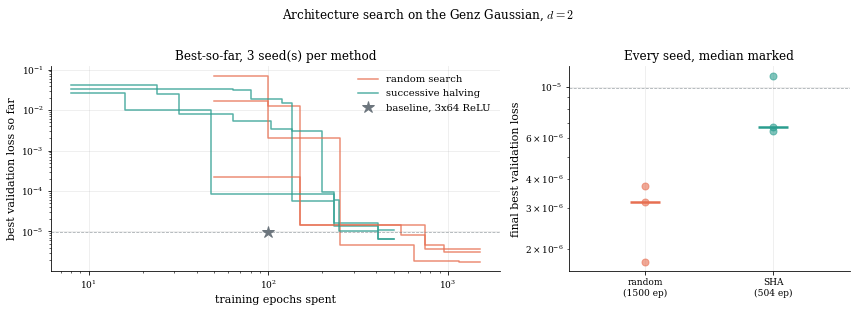

method                epochs   median best val loss                    range
----------------------------------------------------------------------------
baseline                 100              9.834e-06
random search           1500              3.169e-06   [1.753e-06, 3.745e-06]
successive halving       504              6.685e-06   [6.429e-06, 1.118e-05]

SHA spends 34% of random search's epochs.


In [8]:
def best_so_far(records):
    cost, best, out, c, m = [], [], [], 0, np.inf
    for r in records:
        c += r["epochs"]; m = min(m, r["val_loss"]); cost.append(c); best.append(m)
    return np.asarray(cost), np.asarray(best)

rs_final  = np.array([min(r["val_loss"] for r in cache["seeds"][sd]["random"]) for sd in PRESET["seeds"]])
sha_final = np.array([cache["seeds"][sd]["sha_winner"]["val_loss"] for sd in PRESET["seeds"]])
rs_cost   = sum(r["epochs"] for r in cache["seeds"][PRESET["seeds"][0]]["random"])
sha_cost  = sum(r["epochs"] for r in cache["seeds"][PRESET["seeds"][0]]["sha"])
base      = cache.get("baseline", baseline_rec)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
for i, sd in enumerate(PRESET["seeds"]):
    c, b = best_so_far(cache["seeds"][sd]["random"])
    ax.step(c, b, where="post", color=C_RANDOM, alpha=0.8, label="random search" if i == 0 else None)
    c, b = best_so_far(cache["seeds"][sd]["sha"])
    ax.step(c, b, where="post", color=C_SHA, alpha=0.8, label="successive halving" if i == 0 else None)
ax.plot([base["epochs"]], [base["val_loss"]], "*", ms=13, color=C_BASE, label="baseline, 3x64 ReLU")
ax.axhline(base["val_loss"], color=C_BASE, ls="--", lw=0.8, alpha=0.6)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("training epochs spent"); ax.set_ylabel("best validation loss so far")
ax.set_title(f"Best-so-far, {len(PRESET['seeds'])} seed(s) per method"); ax.legend(frameon=False)

ax = axes[1]
for i, (v, col, name) in enumerate([(rs_final, C_RANDOM, f"random\n({rs_cost} ep)"),
                                    (sha_final, C_SHA, f"SHA\n({sha_cost} ep)")]):
    ax.plot([i] * len(v), v, "o", color=col, ms=7, alpha=0.6)
    ax.plot([i], [np.median(v)], "_", color=col, ms=30, mew=2.5)
ax.axhline(base["val_loss"], color=C_BASE, ls="--", lw=0.8, alpha=0.6)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"random\n({rs_cost} ep)", f"SHA\n({sha_cost} ep)"])
ax.set_yscale("log"); ax.set_ylabel("final best validation loss")
ax.set_title("Every seed, median marked"); ax.set_xlim(-0.6, 1.6)
fig.suptitle("Architecture search on the Genz Gaussian, $d = 2$", y=1.02)
fig.tight_layout()
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "nas_search_results.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "nas_search_results.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"{'method':<20s} {'epochs':>7s} {'median best val loss':>22s} {'range':>24s}")
print("-" * 76)
print(f"{'baseline':<20s} {base['epochs']:>7d} {base['val_loss']:>22.3e}")
for name, v, cst in [("random search", rs_final, rs_cost), ("successive halving", sha_final, sha_cost)]:
    print(f"{name:<20s} {cst:>7d} {np.median(v):>22.3e}   [{v.min():.3e}, {v.max():.3e}]")
print(f"\nSHA spends {100*sha_cost/rs_cost:.0f}% of random search's epochs.")

### The winner's surface

The best configuration across both methods and all seeds, retrained from scratch for a longer
budget so that the picture shows the architecture rather than the search transient. This is the
one place the test set is used.

best overall: random search, seed 1, val loss 1.753e-06, 4L 256-224-128-256 relu lr=5.5e-04


retrained: val loss 1.584e-06, test MAE 0.00158; baseline test MAE 0.00294 (ratio baseline / winner = 1.9)


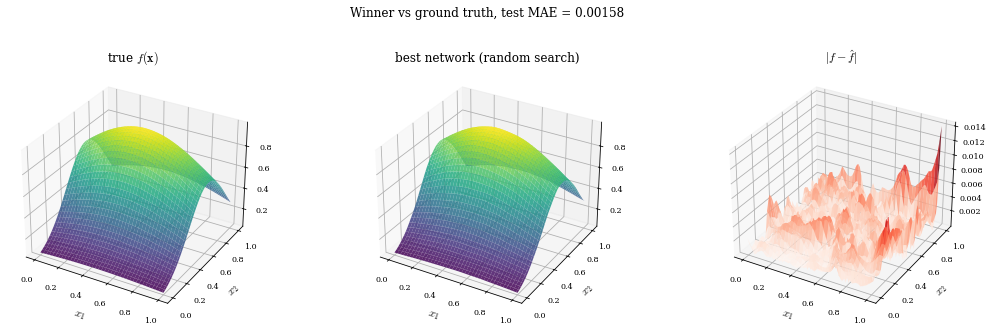

In [9]:
cands = [(min(r["val_loss"] for r in cache["seeds"][sd]["random"]),
          min(cache["seeds"][sd]["random"], key=lambda r: r["val_loss"])["config"], "random search", sd)
         for sd in PRESET["seeds"]]
cands += [(cache["seeds"][sd]["sha_winner"]["val_loss"], cache["seeds"][sd]["sha_winner"]["config"],
           "successive halving", sd) for sd in PRESET["seeds"]]
best_val, best_cfg, best_method, best_seed = min(cands, key=lambda c: c[0])
print(f"best overall: {best_method}, seed {best_seed}, val loss {best_val:.3e}, {describe(best_cfg)}")

tf.keras.utils.set_random_seed(SEED)
final_model = build_model(best_cfg)
final_val   = fit_epochs(final_model, {"smoke": 60, "teaching": 300, "production": 600}[RUN_MODE])
final_mae   = test_mae(final_model)
print(f"retrained: val loss {final_val:.3e}, test MAE {final_mae:.5f}; "
      f"baseline test MAE {base['test_mae']:.5f} (ratio baseline / winner = {base['test_mae']/final_mae:.1f})")

grid_n = 80
_t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(_t, _t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)
Z_true = genz_gaussian(X_grid, c_param, w_param).reshape(grid_n, grid_n)
Z_pred = final_model.predict(X_grid, verbose=0).reshape(grid_n, grid_n)
Z_err  = np.abs(Z_true - Z_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), subplot_kw={"projection": "3d"})
axes[0].plot_surface(X1, X2, Z_true, cmap="viridis", alpha=0.85, edgecolor="none", rcount=60, ccount=60)
axes[0].set_title(r"true $f(\mathbf{x})$")
axes[1].plot_surface(X1, X2, Z_pred, cmap="viridis", alpha=0.85, edgecolor="none", rcount=60, ccount=60)
axes[1].set_title(f"best network ({best_method})")
axes[2].plot_surface(X1, X2, Z_err, cmap="Reds", alpha=0.85, edgecolor="none", rcount=60, ccount=60)
axes[2].set_title(r"$|f - \hat f|$")
for ax in axes:
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.tick_params(labelsize=8)
fig.suptitle(f"Winner vs ground truth, test MAE = {final_mae:.5f}", y=1.02)
fig.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "nas_best_surface.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "nas_best_surface.png", dpi=180, bbox_inches="tight")
plt.show()

### Which knob did the search find?

Group every trial of every seed by one hyperparameter at a time and look at the median validation
loss per level. A hyperparameter that matters separates its levels by orders of magnitude; one that
does not gives a flat row.

In [10]:
all_recs = [r for sd in PRESET["seeds"] for r in cache["seeds"][sd]["random"]]

def by_level(key_fn, levels):
    rows = []
    for lv in levels:
        v = [r["val_loss"] for r in all_recs if key_fn(r["config"]) == lv]
        rows.append((lv, len(v), np.median(v) if v else np.nan))
    return rows

lr_edges = [1e-4, 1e-3, 1e-2, 1e-1]
tables = {
    "learning rate": by_level(lambda c: next(i for i in range(3) if c["lr"] < lr_edges[i+1]*1.0000001),
                              [0, 1, 2]),
    "depth":         by_level(lambda c: c["layers"], LAYER_OPTIONS),
    "activation":    by_level(lambda c: c["activation"], ACT_OPTIONS),
    "mean width":    by_level(lambda c: int(np.mean(c["units"]) > 128), [0, 1]),
}
labels = {"learning rate": ["1e-4 to 1e-3", "1e-3 to 1e-2", "1e-2 to 1e-1"],
          "mean width": ["<= 128", "> 128"]}
for name, rows in tables.items():
    lab = labels.get(name, [str(r[0]) for r in rows])
    meds = [r[2] for r in rows if r[1] > 0]
    print(f"{name:<14s}" + "  ".join(f"{l}: {m:.1e} (n={n})" for l, (_, n, m) in zip(lab, rows) if n > 0)
          + f"   spread {np.nanmax(meds)/np.nanmin(meds):.0f}x")

learning rate 1e-4 to 1e-3: 4.4e-03 (n=30)  1e-3 to 1e-2: 1.9e-04 (n=35)  1e-2 to 1e-1: 8.0e-04 (n=25)   spread 23x
depth         1: 1.2e-02 (n=16)  2: 1.8e-03 (n=12)  3: 6.9e-04 (n=18)  4: 9.0e-05 (n=20)  5: 5.9e-05 (n=24)   spread 197x
activation    relu: 2.8e-05 (n=31)  tanh: 5.0e-04 (n=29)  swish: 6.7e-03 (n=30)   spread 241x
mean width    <= 128: 1.9e-04 (n=25)  > 128: 1.1e-03 (n=65)   spread 6x


---
## 7. The same search on a DEQN

A deep equilibrium net has no labels. Its loss is an equilibrium residual on states the model
visits, and the number one cares about is the Euler-equation error of the trained policy. Nothing
in the search loop changes: a trial trains a policy network and returns a score.

The model is the stochastic Brock-Mirman economy of Session 2 (`02_02`): log utility, capital
share $\alpha = 0.36$, $\beta = 0.99$, $\delta = 0.1$, TFP $\log z_{t+1} = \rho\log z_t +
\sigma\varepsilon_{t+1}$ with $\rho = 0.9$, $\sigma = 0.04$. The network maps $(z_t, k_t)$ to a
savings rate through a sigmoid, the conditional expectation uses five Gauss-Hermite nodes, and the
loss is the squared relative Euler error, all copied from `02_02`. Training states are drawn from
the same box as there, so each trial is independent of every other.

Score: mean absolute relative Euler error on a fixed set of 4,096 held-out states in that box.

| Hyperparameter | Range |
|:---|:---|
| `layers` | $\{1, 2, 3\}$ |
| `units` | $\{16, 32, 64, 128\}$ |
| `activation` | relu, tanh |
| `lr` | log-uniform on $[10^{-4}, 10^{-2}]$ |

In [11]:
# ---------------------------------------------------------------- model, from 02_02
alpha, beta, delta = 0.36, 0.99, 0.1
sigma_tfp, rho_tfp = 0.04, 0.9
n_int = 5
_x, _w = np.polynomial.hermite.hermgauss(n_int)
w_int = tf.constant(_w / np.sqrt(np.pi), tf.float32)
x_int = tf.constant(_x * np.sqrt(2.0) * sigma_tfp, tf.float32)
z_lb, z_ub, k_lb, k_ub = 0.7, 1.3, 0.9, 12.0


def sample_states(n):
    return tf.concat([tf.random.uniform((n, 1), z_lb, z_ub),
                      tf.random.uniform((n, 1), k_lb, k_ub)], axis=1)


def build_policy(cfg):
    m = keras.Sequential([keras.Input(shape=(2,))])
    for _ in range(cfg["layers"]):
        m.add(layers.Dense(cfg["units"], activation=cfg["activation"]))
    m.add(layers.Dense(1, activation="sigmoid"))
    return m


def make_deqn_fns(nn, opt):
    def inside(X1):                                   # term inside the expectation, as in 02_02
        Z1, K1 = X1[:, :1], X1[:, 1:]
        Y1 = Z1 * K1**alpha
        r1 = alpha * Z1 * K1**(alpha - 1.0)
        C1 = Y1 * (1.0 - nn(X1))
        return (1.0 / C1) * (1.0 - delta + r1)

    def rel_euler_error(X):
        Z, K = X[:, :1], X[:, 1:]
        Y = Z * K**alpha
        s = nn(X)
        K1 = (1.0 - delta) * K + Y * s
        C = Y * (1.0 - s)
        E = 0.0
        for i in range(n_int):
            Z1 = tf.exp(rho_tfp * tf.math.log(Z) + x_int[i])
            E = E + w_int[i] * inside(tf.concat([Z1, K1], axis=1))
        return 1.0 - 1.0 / (C * beta * E)

    @tf.function
    def step(X):
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean(rel_euler_error(X)**2)
        opt.apply_gradients(zip(tape.gradient(loss, nn.trainable_variables), nn.trainable_variables))
        return loss

    @tf.function
    def score(X):
        return tf.reduce_mean(tf.abs(rel_euler_error(X)))

    return step, score


tf.random.set_seed(SEED)
X_hold = sample_states(4096)

DEQN_PRESET = {"smoke": dict(n_trials=6, episodes=500), "teaching": dict(n_trials=30, episodes=3000),
               "production": dict(n_trials=60, episodes=10000)}[RUN_MODE]
D_LAYERS, D_UNITS, D_ACTS = [1, 2, 3], [16, 32, 64, 128], ["relu", "tanh"]


def sample_deqn_config(rng):
    return {"layers": int(rng.choice(D_LAYERS)), "units": int(rng.choice(D_UNITS)),
            "activation": str(rng.choice(D_ACTS)), "lr": float(10.0 ** rng.uniform(-4.0, -2.0))}


def deqn_trial(cfg, episodes, seed):
    tf.keras.utils.set_random_seed(seed)
    nn, opt = build_policy(cfg), keras.optimizers.Adam(cfg["lr"])
    step, score = make_deqn_fns(nn, opt)
    t0 = time.perf_counter()
    for ep in range(episodes):
        step(sample_states(128))
    return {"config": cfg, "score": float(score(X_hold)), "episodes": episodes,
            "time": time.perf_counter() - t0}


if DEQN_CACHE.exists():
    deqn_records = pickle.load(open(DEQN_CACHE, "rb"))
    print(f"loaded {DEQN_CACHE} ({len(deqn_records)} trials); delete it to re-run the sweep")
else:
    rng, deqn_records, t0 = np.random.default_rng(SEED), [], time.perf_counter()
    for i in range(DEQN_PRESET["n_trials"]):
        rec = deqn_trial(sample_deqn_config(rng), DEQN_PRESET["episodes"], seed=SEED * 1000 + i)
        deqn_records.append(rec)
        print(f"  trial {i+1:>2d}/{DEQN_PRESET['n_trials']}: mean |Euler error| {rec['score']:.2e}  "
              f"{rec['config']['layers']}x{rec['config']['units']} {rec['config']['activation']} "
              f"lr={rec['config']['lr']:.1e}  ({rec['time']:.0f}s)")
    pickle.dump(deqn_records, open(DEQN_CACHE, "wb"))
    print(f"wrote {DEQN_CACHE} ({time.perf_counter()-t0:.0f}s)")

ranked = sorted(deqn_records, key=lambda r: r["score"])
print(f"\n{'rank':>4s}  {'mean |Euler error|':>18s}  {'depth':>5s} {'width':>5s} {'act':>5s} {'lr':>8s}")
for i, r in enumerate(ranked):
    c = r["config"]
    print(f"{i+1:>4d}  {r['score']:>18.2e}  {c['layers']:>5d} {c['units']:>5d} {c['activation']:>5s} {c['lr']:>8.1e}")

# the 02_02 default, for reference: 2 x 50 relu, lr 3e-4
ref = deqn_trial({"layers": 2, "units": 50, "activation": "relu", "lr": 3e-4}, DEQN_PRESET["episodes"], seed=SEED)
print(f"\n02_02 default (2x50 relu, lr 3e-4) at the same budget: {ref['score']:.2e}")
print(f"best found: {ranked[0]['score']:.2e}, worst: {ranked[-1]['score']:.2e}, "
      f"{ranked[-1]['score']/ranked[0]['score']:.0f}x apart")

for name, key, levels in [("depth", lambda c: c["layers"], D_LAYERS),
                          ("width", lambda c: c["units"], D_UNITS),
                          ("activation", lambda c: c["activation"], D_ACTS),
                          ("lr decade", lambda c: int(np.floor(np.log10(c["lr"]) + 1e-9)), [-4, -3])]:
    meds = []
    for lv in levels:
        v = [r["score"] for r in deqn_records if key(r["config"]) == lv]
        meds.append((lv, len(v), np.median(v) if v else np.nan))
    valid = [m for _, n, m in meds if n > 0]
    print(f"{name:<11s}" + "  ".join(f"{lv}: {m:.1e} (n={n})" for lv, n, m in meds if n > 0)
          + f"   spread {max(valid)/min(valid):.1f}x")

  trial  1/30: mean |Euler error| 2.32e-03  3x64 tanh lr=1.2e-04  (19s)


  trial  2/30: mean |Euler error| 7.47e-03  1x16 relu lr=4.2e-03  (15s)


  trial  3/30: mean |Euler error| 4.49e-04  2x128 tanh lr=2.9e-03  (21s)


  trial  4/30: mean |Euler error| 9.75e-04  2x64 tanh lr=7.4e-03  (18s)


  trial  5/30: mean |Euler error| 1.97e-03  1x128 tanh lr=5.2e-03  (17s)


...

  trial 27/30: mean |Euler error| 1.60e-03  3x64 tanh lr=7.7e-03  (19s)


  trial 28/30: mean |Euler error| 7.91e-03  1x16 relu lr=1.6e-04  (17s)


  trial 29/30: mean |Euler error| 1.69e-03  2x64 tanh lr=7.6e-04  (17s)


  trial 30/30: mean |Euler error| 9.79e-04  3x32 tanh lr=1.0e-03  (17s)
wrote nas_results/deqn_search_teaching.pkl (544s)

rank  mean |Euler error|  depth width   act       lr
   1            2.38e-04      3    32  tanh  2.0e-03
   2            3.86e-04      2    16  tanh  3.9e-03
   3            4.49e-04      2   128  tanh  2.9e-03
   4            5.83e-04      2   128  relu  5.7e-03
   5            6.27e-04      1    64  tanh  1.7e-03
   6            6.54e-04      2    64  tanh  1.1e-03
   7            9.75e-04      2    64  tanh  7.4e-03
   8            9.79e-04      3    32  tanh  1.0e-03
   9            1.05e-03      3    64  relu  1.5e-03
  10            1.41e-03      1   128  relu  1.8e-03
  11            1.57e-03      3    32  relu  9.2e-03
  12            1.58e-03      2    16  tanh  5.2e-04
  13            1.60e-03      3    64  tanh  7.7e-03
  14            1.69e-03      2    64  tanh  7.6e-04
  15            1.97e-03      1   128  tanh  5.2e-03
  16            1.98e-03     


02_02 default (2x50 relu, lr 3e-4) at the same budget: 2.05e-03
best found: 2.38e-04, worst: 7.91e-03, 33x apart
depth      1: 3.4e-03 (n=10)  2: 1.6e-03 (n=11)  3: 1.6e-03 (n=9)   spread 2.2x
width      16: 3.5e-03 (n=9)  32: 1.6e-03 (n=5)  64: 1.8e-03 (n=12)  128: 1.0e-03 (n=4)   spread 3.5x
activation relu: 2.2e-03 (n=15)  tanh: 1.6e-03 (n=15)   spread 1.4x
lr decade  -4: 2.2e-03 (n=12)  -3: 1.5e-03 (n=18)   spread 1.5x


---
## 8. What to remember

1. **Rank on validation, report on test.** The search sees the validation set thousands of
   times; the number that describes the winner has to come from data the search never saw.

2. **Compare on the budget axis.** Successive halving looks at more configurations for fewer
   epochs. On the epoch axis both methods are judged by the same currency.

3. **Continue, do not restart.** A promoted configuration keeps its weights. That is what makes
   the rung budgets add up, and it is also what libraries do under the hood.

4. **Report a spread.** With one seed either method can win. The table in Section 6 gives the
   median and the range; read the range before the median.

5. **The search loop does not care what the score is.** A validation loss, an Euler error, a
   moment distance: a trial is a function from a configuration to a number. Section 7 changed the
   score and nothing else.

6. **Which knob matters depends on the problem, and the search tells you.** With the architecture
   fixed, `03_01` found the learning rate to be the sharp axis. Across architectures on the Genz
   target, activation and depth separated the trials by two orders of magnitude and the
   learning-rate decade by one. On the DEQN, width mattered most. Read the per-level table before
   trusting a rule of thumb.

### References

- Bergstra, J., and Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal
  of Machine Learning Research* 13, 281-305.
- Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., and Talwalkar, A. (2018). Hyperband: a
  novel bandit-based approach to hyperparameter optimization. *Journal of Machine Learning
  Research* 18(185), 1-52.
- Jamieson, K., and Talwalkar, A. (2016). Non-stochastic best arm identification and hyperparameter
  optimization. *AISTATS*. (Successive halving for hyperparameters.)

In [12]:
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f}s")

RUN_MODE = teaching; notebook wall-clock 1748s
